# 📊 Digital Diagnosis — Dataset Analysis
This notebook answers the key questions about our dataset:
1. **How many total diseases are in the dataset?**
2. **How many total unique symptoms?**
3. **How many rows (samples) per disease?**
4. **Symptom co-occurrence heatmap**
5. **Class balance analysis**

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────
ROOT       = Path('..').resolve()
DATA_DIR   = ROOT / 'data'
CSV_PATH   = DATA_DIR / 'disease_dataset_clean.csv'
SYM_PATH   = DATA_DIR / 'symptom_list_clean.txt'

print(f'Root          : {ROOT}')
print(f'Dataset file  : {CSV_PATH}')
print(f'Symptom list  : {SYM_PATH}')

Root          : D:\ml_udemy\00 ML CODE\Projects\Digital Diagnosis v2
Dataset file  : D:\ml_udemy\00 ML CODE\Projects\Digital Diagnosis v2\data\disease_dataset_clean.csv
Symptom list  : D:\ml_udemy\00 ML CODE\Projects\Digital Diagnosis v2\data\symptom_list_clean.txt


## 1. Load Dataset

In [2]:
df = pd.read_csv(CSV_PATH)
print(f'Shape  : {df.shape[0]:,} rows  ×  {df.shape[1]} columns')
df.head()

Shape  : 2,502 rows  ×  85 columns


,disease,agitation,angina_pectoris,arm_weakness,ascites,asthenia,calf_pain_walking,chest_tightness,chill,confusion,...,sore_throat,tremor,unresponsiveness,vomiting,weepiness,weight_gain,wheezing,worry,yellow_eyes,yellow_skin
0,hypertensive disease,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,hypertensive disease,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,hypertensive disease,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,hypertensive disease,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,hypertensive disease,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 2. Total Diseases & Unique Symptoms

In [3]:
# ── Diseases ──────────────────────────────────────────────────────
# The last column is the label column (disease name)
label_col  = df.columns[-1]            # e.g. 'prognosis' or 'disease'
diseases   = df[label_col].unique()
n_diseases = len(diseases)

# ── Symptoms ──────────────────────────────────────────────────────
# All columns except the label column are symptom binary flags
symptom_cols = [c for c in df.columns if c != label_col]
n_symptoms   = len(symptom_cols)

# Cross-check with the official symptom list file
with open(SYM_PATH, 'r') as f:
    official_symptoms = [line.strip() for line in f if line.strip()]

print('=' * 50)
print(f'  Total diseases (unique)  : {n_diseases}')
print(f'  Total symptom columns    : {n_symptoms}')
print(f'  Official symptom list    : {len(official_symptoms)}')
print(f'  Total rows in dataset    : {len(df):,}')
print('=' * 50)
print()
print('All disease names:')
for i, d in enumerate(sorted(diseases), 1):
    print(f'  {i:2d}. {d}')

  Total diseases (unique)  : 2
  Total symptom columns    : 84
  Official symptom list    : 84
  Total rows in dataset    : 2,502

All disease names:
   1. 0
   2. 1


## 3. Rows Per Disease

In [4]:
rows_per_disease = df[label_col].value_counts().sort_values(ascending=False)

print(f'\nRows per disease:')
print(f'{"Disease":<45} {"Count":>7}  {"% of total":>10}')
print('-' * 65)
for disease, count in rows_per_disease.items():
    pct = count / len(df) * 100
    print(f'{disease:<45} {count:>7}  {pct:>9.2f}%')
    
print(f'\nMin rows: {rows_per_disease.min()} | Max rows: {rows_per_disease.max()} | Mean: {rows_per_disease.mean():.1f}')


Rows per disease:
Disease                                         Count  % of total
-----------------------------------------------------------------
0                                                2399      95.88%
1                                                 103       4.12%

Min rows: 103 | Max rows: 2399 | Mean: 1251.0


## 4. Visualise: Samples per Disease

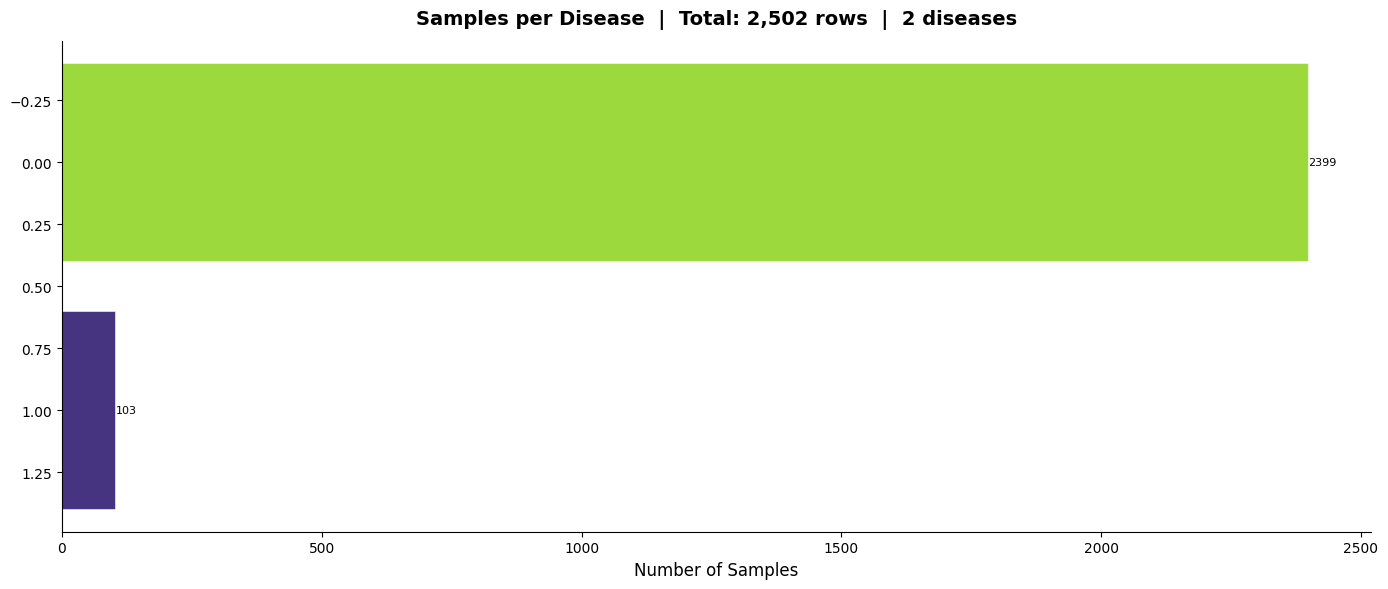

Chart saved.


In [5]:
fig, ax = plt.subplots(figsize=(14, max(6, n_diseases * 0.30)))

colors = cm.viridis_r(np.linspace(0.15, 0.85, len(rows_per_disease)))

bars = ax.barh(
    rows_per_disease.index,
    rows_per_disease.values,
    color=colors,
    edgecolor='white',
    linewidth=0.4
)

for bar, val in zip(bars, rows_per_disease.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', ha='left', fontsize=8)

ax.set_xlabel('Number of Samples', fontsize=12)
ax.set_title(f'Samples per Disease  |  Total: {len(df):,} rows  |  {n_diseases} diseases',
             fontsize=14, fontweight='bold', pad=12)
ax.invert_yaxis()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'samples_per_disease.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

## 5. Symptom Frequency (Top 20)

In [6]:
# How often each symptom appears across ALL rows
symptom_freq = df[symptom_cols].sum().sort_values(ascending=False)

top20 = symptom_freq.head(20)

fig, ax = plt.subplots(figsize=(12, 5))
colors2  = cm.plasma(np.linspace(0.15, 0.85, 20))

ax.bar(top20.index, top20.values, color=colors2, edgecolor='white', linewidth=0.4)
ax.set_xticklabels(top20.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Occurrence count', fontsize=11)
ax.set_title('Top 20 Most Frequent Symptoms in Dataset', fontsize=13, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'top20_symptoms.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

UFuncTypeError: ufunc 'greater' did not contain a loop with signature matching types (<class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.StrDType'>) -> None

## 6. Class Balance Check

In [7]:
count_stats = rows_per_disease.describe()
print('Class balance statistics:')
print(count_stats.to_string())

balanced = rows_per_disease.std() / rows_per_disease.mean()
print(f'\nCoefficient of variation (CV) : {balanced:.3f}')
print(f'(CV < 0.20 = balanced   |   CV > 0.50 = imbalanced)')

Class balance statistics:
count       2.00000
mean     1251.00000
std      1623.51717
min       103.00000
25%       677.00000
50%      1251.00000
75%      1825.00000
max      2399.00000

Coefficient of variation (CV) : 1.298
(CV < 0.20 = balanced   |   CV > 0.50 = imbalanced)


## 7. Summary Table

In [8]:
summary = pd.DataFrame({
    'Metric': [
        'Total rows in dataset',
        'Total unique diseases',
        'Total symptom features (columns)',
        'Official symptom list size',
        'Min rows per disease',
        'Max rows per disease',
        'Mean rows per disease',
    ],
    'Value': [
        f'{len(df):,}',
        n_diseases,
        n_symptoms,
        len(official_symptoms),
        rows_per_disease.min(),
        rows_per_disease.max(),
        f'{rows_per_disease.mean():.1f}',
    ]
})

print(summary.to_string(index=False))

                          Metric  Value
           Total rows in dataset  2,502
           Total unique diseases      2
Total symptom features (columns)     84
      Official symptom list size     84
            Min rows per disease    103
            Max rows per disease   2399
           Mean rows per disease 1251.0
